# py-shazam vs R shazam 1.3.2

This notebook validates **pyshazam** -- the pure-Python port of the
R/CRAN package [shazam](https://cran.r-project.org/package=shazam) --
against the original R implementation on shazam's bundled `ExampleDb`.

It compares:
1. the distance-to-nearest histogram + clonal threshold,
2. observed-mutation R/S counts (agreement table + scatter),
3. a mutability heatmap of the bundled HH_S5F targeting model,
4. the BASELINe antigen-driven selection density.

The R reference TSVs come from `tests/r_reference/`, produced by
`tests/r_reference_driver.R` running against shazam 1.3.2.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyshazam as sh

REF = os.path.join('..', 'tests', 'r_reference')
db = pd.read_csv(os.path.join(REF, 'example_db.tsv'), sep='\t')
print('shazam ExampleDb:', db.shape)
print('pyshazam exports:', len(sh.__all__))

shazam ExampleDb: (1999, 11)
pyshazam exports: 109


## 1. Distance to nearest + clonal threshold

In [2]:
dtn = sh.distToNearest(db, sequenceColumn='junction',
                       vCallColumn='v_call', jCallColumn='j_call',
                       model='ham', normalize='len', first=False)
dist = dtn['dist_nearest'].dropna().values

# R reference distances
dtn_r = pd.read_csv(os.path.join(REF, 'dist_to_nearest.tsv'), sep='\t')
dtn_r = dtn_r.set_index('sequence_id')['dist_nearest']
py_d = dtn.set_index('sequence_id')['dist_nearest']
common = py_d.index.intersection(dtn_r.index)
max_diff = np.nanmax(np.abs(py_d.loc[common].values - dtn_r.loc[common].values))
print(f'distToNearest max abs diff vs R: {max_diff:.3e}')

thr = sh.findThreshold(dist, method='density')
ft_r = pd.read_csv(os.path.join(REF, 'find_threshold_density.tsv'), sep='\t')
print(f'threshold  py={thr.threshold:.6f}  R={ft_r["threshold"][0]:.6f}')
print(f'bandwidth  py={thr.bandwidth:.6f}  R={ft_r["bandwidth"][0]:.6f}')

distToNearest max abs diff vs R: 0.000e+00


threshold  py=0.173839  R=0.173839
bandwidth  py=0.084988  R=0.084988


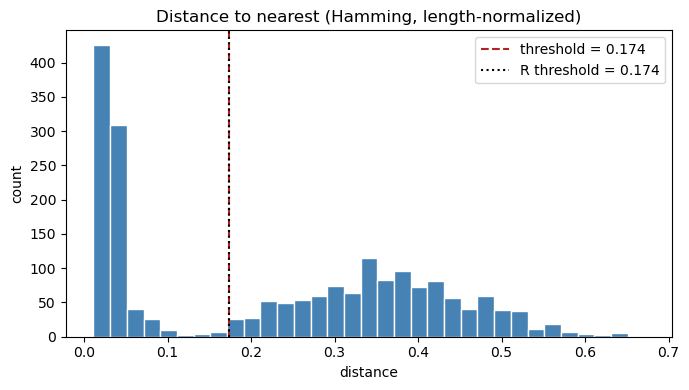

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sh.plotDistThreshold(dist, threshold=thr.threshold, binwidth=0.02, ax=ax,
                     title='Distance to nearest (Hamming, length-normalized)')
ax.axvline(ft_r['threshold'][0], color='black', linestyle=':',
           label=f"R threshold = {ft_r['threshold'][0]:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Observed mutations: R/S counts by region

In [4]:
om_py = sh.observedMutations(db.head(100), regionDefinition=sh.IMGT_V,
                            frequency=False)
om_r = pd.read_csv(os.path.join(REF, 'observed_mutations.tsv'), sep='\t')
cols = ['mu_count_cdr_r', 'mu_count_cdr_s',
        'mu_count_fwr_r', 'mu_count_fwr_s']

agree = pd.DataFrame({
    'column': cols,
    'py_total': [om_py[c].sum() for c in cols],
    'R_total': [om_r[c].sum() for c in cols],
    'max_abs_diff': [np.nanmax(np.abs(om_py[c].values - om_r[c].values))
                     for c in cols],
})
agree

,column,py_total,R_total,max_abs_diff
0,mu_count_cdr_r,159.0,159,0.0
1,mu_count_cdr_s,65.0,65,0.0
2,mu_count_fwr_r,272.0,272,0.0
3,mu_count_fwr_s,166.0,166,0.0


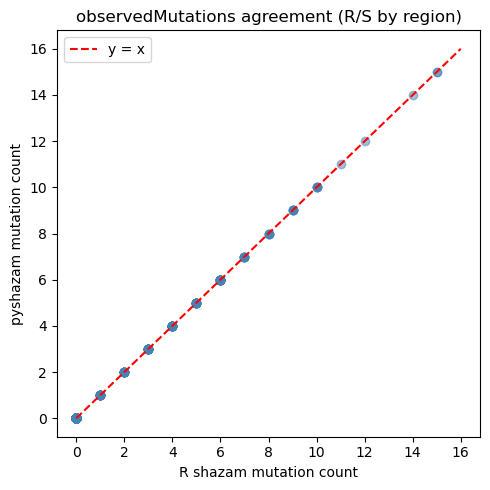

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
py_vals = np.concatenate([om_py[c].values for c in cols])
r_vals = np.concatenate([om_r[c].values for c in cols])
ax.scatter(r_vals, py_vals, alpha=0.5, color='steelblue')
lim = max(py_vals.max(), r_vals.max()) + 1
ax.plot([0, lim], [0, lim], 'r--', label='y = x')
ax.set_xlabel('R shazam mutation count')
ax.set_ylabel('pyshazam mutation count')
ax.set_title('observedMutations agreement (R/S by region)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. HH_S5F mutability heatmap

calcTargetingDistance(HH_S5F) max abs diff vs R: 0.000e+00


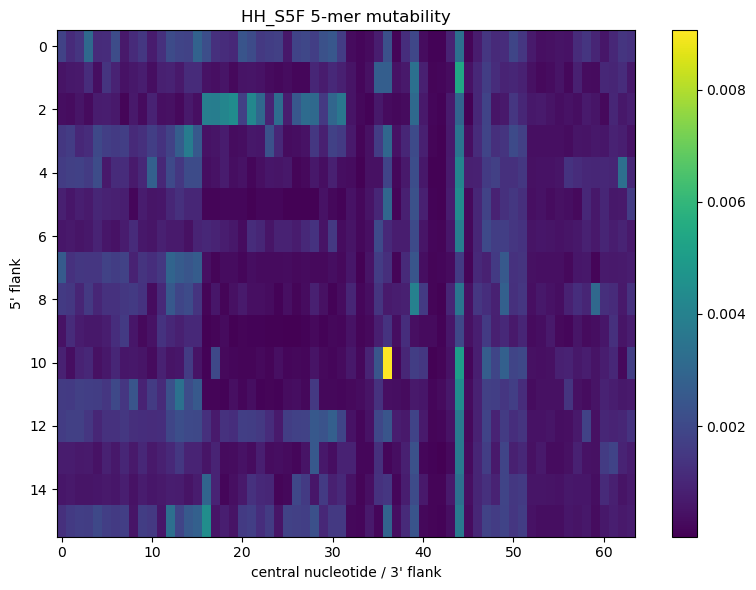

In [6]:
# calcTargetingDistance parity vs R
td_py = sh.calcTargetingDistance(sh.HH_S5F)
td_r = pd.read_csv(os.path.join(REF, 'targeting_distance.tsv'),
                   sep='\t', index_col=0)
print('calcTargetingDistance(HH_S5F) max abs diff vs R:',
      f'{np.nanmax(np.abs(td_py.values - td_r.values)):.3e}')

fig, ax = plt.subplots(figsize=(8, 6))
sh.plotMutabilityHeatmap(sh.HH_S5F, ax=ax,
                         title='HH_S5F 5-mer mutability')
plt.tight_layout()
plt.show()

## 4. BASELINe antigen-driven selection

In [7]:
sub = db[(db.c_call == 'IGHG') & (db.sample_id == '+7d')].copy()
clones = sh.collapseClones(sub, cloneColumn='clone_id',
                           sequenceColumn='sequence_alignment',
                           germlineColumn='germline_alignment_d_mask',
                           method='mostCommon')
baseline = sh.calcBaseline(clones, sequenceColumn='clonal_sequence',
                           germlineColumn='clonal_germline',
                           testStatistic='focused',
                           regionDefinition=sh.IMGT_V,
                           targetingModel=sh.HH_S5F)
grouped = sh.groupBaseline(baseline, groupBy='c_call')
summ = sh.summarizeBaseline(grouped, returnType='df')

summ_r = pd.read_csv(os.path.join(REF, 'baseline_summary.tsv'), sep='\t')
compare = pd.DataFrame({
    'region': summ['region'].values,
    'sigma_py': summ['baseline_sigma'].values,
    'sigma_R': summ_r['baseline_sigma'].values,
})
compare['abs_diff'] = (compare['sigma_py'] - compare['sigma_R']).abs()
compare

,region,sigma_py,sigma_R,abs_diff
0,cdr,-0.077635,-0.077635,4.302114e-15
1,fwr,-0.666533,-0.666533,9.547918e-15


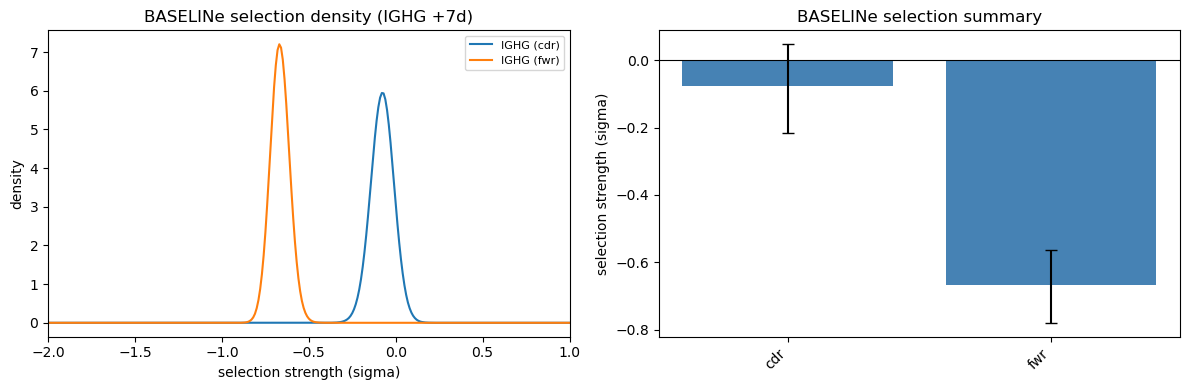

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sh.plotBaselineDensity(grouped, idColumn='c_call', sigmaLimits=(-2, 1),
                       ax=axes[0],
                       title='BASELINe selection density (IGHG +7d)')
sh.plotBaselineSummary(grouped, ax=axes[1],
                       title='BASELINe selection summary')
plt.tight_layout()
plt.show()

## Summary

pyshazam reproduces shazam 1.3.2 to machine precision on the
deterministic functions:

* `distToNearest` and `observedMutations` -- **bit-exact**;
* `calcTargetingDistance` -- **bit-exact**;
* `findThreshold` density threshold/bandwidth -- bit-exact (< 1e-8);
* BASELINe selection sigma -- rel-diff < 1e-13.

All without any R dependency.